                                FINAL PROJECT : Exploring Jobs in Tech: A Data Wrangling Study
______________________________________________________________________________________________________________________________________
                                        Name = Komal Shahid
                                        Version = Final Draft (merged notebooks)
                                        Date = March 2, 2024
_____________________________

                                        __DSC540 Final Project Milestone__
______________________




                                            imported libraries 
_______________________________________________________________________________________________________________________________________

In [1]:
#imported libraries 
import pandas as pd
import numpy as np
import re
from fuzzywuzzy import fuzz
from scipy import stats
from fuzzywuzzy import process
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import requests
from bs4 import BeautifulSoup
import sqlite3

In [2]:
# Read the Kaggle Survey dataset into a DataFrame
df = pd.read_csv('kaggle-survey-2021/kaggle_survey_2021_responses.csv', low_memory= False)
df.head()

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                            Drop the first row from each column because the data starts from row 1
_____________________________________

In [3]:
## Since row 0 is the question being asked in the survey
df = df.iloc[1:]
df.head()

,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,784,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,NaN,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Python,NaN,NaN,...,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                                Shorten the dataset to keep the columns of interest only
______________________________________________________________________________________________________

In [4]:
columns_to_keep = ['Q1', 'Q2', 'Q3','Q4','Q5','Q6',
                   'Q7_Part_1','Q7_Part_2','Q7_Part_3','Q7_Part_4','Q7_Part_5',
                   'Q7_Part_6','Q7_Part_7','Q7_Part_8','Q7_Part_9','Q7_Part_10','Q7_Part_11',
                   'Q7_Part_12','Q7_OTHER',
                   'Q20','Q21','Q25']  
subset_df = df[columns_to_keep]
# Print the subset DataFrame
print(subset_df.head())

      Q1   Q2         Q3                 Q4                       Q5  \
1  50-54  Man      India  Bachelor’s degree                    Other   
2  50-54  Man  Indonesia    Master’s degree  Program/Project Manager   
3  22-24  Man   Pakistan    Master’s degree        Software Engineer   
4  45-49  Man     Mexico    Doctoral degree       Research Scientist   
5  45-49  Man      India    Doctoral degree                    Other   

           Q6 Q7_Part_1 Q7_Part_2 Q7_Part_3 Q7_Part_4  ... Q7_Part_7  \
1  5-10 years    Python         R       NaN       NaN  ...       NaN   
2   20+ years       NaN       NaN       SQL         C  ...       NaN   
3   1-3 years    Python       NaN       NaN       NaN  ...       NaN   
4   20+ years    Python       NaN       NaN       NaN  ...       NaN   
5   < 1 years    Python       NaN       NaN         C  ...       NaN   

  Q7_Part_8 Q7_Part_9 Q7_Part_10 Q7_Part_11 Q7_Part_12 Q7_OTHER  \
1       NaN       NaN        NaN        NaN        NaN      NaN   


                                    Combine the column whose answer is split into multiple columns 
____________________________

In [5]:
# Create a new column by combining multiple columns based on another column
## form the dataset, you can see that question 7 has multiple parts and even though it is string data type because of nan values,
## there is inconsistent datatype for the columns from str to float. 
subset_df['Q7'] = subset_df.apply(lambda row: ', '.join([str(row['Q7_Part_1']), str(row['Q7_Part_2']), str(row['Q7_Part_3']), str(row['Q7_Part_4']),
                                           str(row['Q7_Part_5']),str(row['Q7_Part_6']),str(row['Q7_Part_7']),str(row['Q7_Part_8']),
                                           str(row['Q7_Part_9']),str(row['Q7_Part_10']),str(row['Q7_Part_11']),
                                           str(row['Q7_Part_12']),str(row['Q7_OTHER'])]), axis=1)
# Convert NaN values to empty string and then removing them from Q7 column
# Replace NaN values with an empty string
subset_df['Q7']= subset_df['Q7'].fillna('')

# Remove unwanted commas from the combined column
subset_df.loc[:,'Q7'] = subset_df['Q7'].str.replace(r'(^,)|(,$)|,(?=,)|nan, ', '').str.strip()
# the regular expressions (`(^,)|(,$)|,(?=,)|nan, `) are used in the `str.replace()` function to remove unwanted commas.
# The first part `(^,)` matches commas at the start of a string and replaces them with an empty string. 
# ($,) matches commas at the end of a string.
# ,(?=,) matches consecutive commas and replaces them with an empty string.
# Print the string for q7 to see if it needs more transformation
print(subset_df["Q7"])

1        Python, R, nan, nan, nan, nan, nan, nan, nan, ...
2        nan, nan, SQL, C, C++, Java, nan, nan, nan, na...
3        Python, nan, nan, nan, C++, Java, nan, nan, na...
4        Python, nan, nan, nan, nan, nan, nan, nan, nan...
5        Python, nan, nan, C, nan, nan, nan, nan, nan, ...
                               ...                        
25969    Python, nan, SQL, nan, nan, nan, Javascript, n...
25970    Python, nan, nan, nan, nan, nan, nan, nan, nan...
25971    nan, nan, nan, nan, nan, nan, nan, nan, nan, n...
25972    Python, nan, SQL, nan, nan, nan, nan, nan, nan...
25973    nan, nan, nan, nan, nan, nan, nan, nan, nan, n...
Name: Q7, Length: 25973, dtype: object


/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_16193/456572330.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Q7'] = subset_df.apply(lambda row: ', '.join([str(row['Q7_Part_1']), str(row['Q7_Part_2']), str(row['Q7_Part_3']), str(row['Q7_Part_4']),
/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_16193/456572330.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Q7']= subset_df['Q7'].fillna('')


                                Transformation of replacing nan values for the combined column
___________________

In [6]:
# Replace NaN values at the end along with the comma with an empty string
subset_df['Q7']=subset_df['Q7'].str.replace(', nan', '').str.strip()
subset_df = subset_df.replace('nan', '')
subset_df['Q7']

/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_16193/174453248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Q7']=subset_df['Q7'].str.replace(', nan', '').str.strip()


1                            Python, R
2               nan, SQL, C, C++, Java
3                    Python, C++, Java
4                               Python
5                    Python, C, MATLAB
                     ...              
25969    Python, SQL, Javascript, Bash
25970                           Python
25971                                 
25972                      Python, SQL
25973                                 
Name: Q7, Length: 25973, dtype: object

##### Repeat step 2: keep the combined response column and drop the rest

In [7]:
columns_to_keep = ['Q1', 'Q2', 'Q3','Q4','Q5','Q6',
                   'Q20','Q21','Q25','Q7']  
subset_df = subset_df[columns_to_keep]
# Print the subset DataFrame

print(subset_df.head())

      Q1   Q2         Q3                 Q4                       Q5  \
1  50-54  Man      India  Bachelor’s degree                    Other   
2  50-54  Man  Indonesia    Master’s degree  Program/Project Manager   
3  22-24  Man   Pakistan    Master’s degree        Software Engineer   
4  45-49  Man     Mexico    Doctoral degree       Research Scientist   
5  45-49  Man      India    Doctoral degree                    Other   

           Q6                        Q20                   Q21            Q25  \
1  5-10 years  Manufacturing/Fabrication      50-249 employees  25,000-29,999   
2   20+ years  Manufacturing/Fabrication  1000-9,999 employees  60,000-69,999   
3   1-3 years        Academics/Education  1000-9,999 employees         $0-999   
4   20+ years        Academics/Education  1000-9,999 employees  30,000-39,999   
5   < 1 years        Academics/Education      50-249 employees  30,000-39,999   

                       Q7  
1               Python, R  
2  nan, SQL, C, C++, Jav

                                                    Headers with appropriate names
_____________________________________

In [8]:
# Replace Headers with appropriate names
subset_df = subset_df.rename(columns={"Q1": "age(in_years)",
                       "Q2": "gender", "Q3": "country" , "Q4": "highest_lvl_educ", "Q5": "job_role" ,
                        "Q6": "programming_exp(in_years)" , 
                        "Q7" : "programming_lang", "Q20" : "curr_industry",
                         "Q21": "company_size" , "Q25": "salary"
                       })

# Print the DataFrame with updated column header
subset_df


,age(in_years),gender,country,highest_lvl_educ,job_role,programming_exp(in_years),curr_industry,company_size,salary,programming_lang
1,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Manufacturing/Fabrication,50-249 employees,"25,000-29,999","Python, R"
2,50-54,Man,Indonesia,Master’s degree,Program/Project Manager,20+ years,Manufacturing/Fabrication,"1000-9,999 employees","60,000-69,999","nan, SQL, C, C++, Java"
3,22-24,Man,Pakistan,Master’s degree,Software Engineer,1-3 years,Academics/Education,"1000-9,999 employees",$0-999,"Python, C++, Java"
4,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Academics/Education,"1000-9,999 employees","30,000-39,999",Python
5,45-49,Man,India,Doctoral degree,Other,< 1 years,Academics/Education,50-249 employees,"30,000-39,999","Python, C, MATLAB"
...,...,...,...,...,...,...,...,...,...,...
25969,30-34,Man,Egypt,Bachelor’s degree,Data Analyst,1-3 years,Computers/Technology,"10,000 or more employees","15,000-19,999","Python, SQL, Javascript, Bash"
25970,22-24,Man,China,Master’s degree,Student,1-3 years,NaN,NaN,NaN,Python
25971,50-54,Man,Sweden,Doctoral degree,Research Scientist,I have never written code,Academics/Education,"1000-9,999 employees",$0-999,
25972,45-49,Man,United States of America,Master’s degree,Data Scientist,5-10 years,Online Service/Internet-based Services,"10,000 or more employees",NaN,"Python, SQL"


                                        Count the null values/missing values in the columns
________________________

In [9]:

# Calculate the number of NaN values for each column
nan_counts = subset_df.isna().sum()
# Print the number of NaN values for each column
print(nan_counts)
empty_strings =  subset_df.apply(lambda x: (x == '').sum())
print(f' \nThe missing values for the columns are: \n{empty_strings}')

age(in_years)                    0
gender                           0
country                          0
highest_lvl_educ                 0
job_role                         0
programming_exp(in_years)        0
curr_industry                 9648
company_size                  9722
salary                       10582
programming_lang                 0
dtype: int64
 
The missing values for the columns are: 
age(in_years)                   0
gender                          0
country                         0
highest_lvl_educ                0
job_role                        0
programming_exp(in_years)       0
curr_industry                   0
company_size                    0
salary                          0
programming_lang             1351
dtype: int64


                    Identifying the unique values in the columns since most of the data is categircal data
______________________________________________________________________

In [10]:
# Find unique values in each column to identify
# if the match with the survey and find outliers or inconsistent 
# since the data is not numeric, graphing the data or using box plot wouldn't work
unique_values = subset_df.apply(lambda x: x.unique())
for column in unique_values.index:
    print(column, ":")
    count = 0
    for value in unique_values[column]:
        print("-", value)
        count += 1
        if count == 15:
            break
    print()# Print the unique values in each column

age(in_years) :
- 50-54
- 22-24
- 45-49
- 25-29
- 18-21
- 30-34
- 40-44
- 35-39
- 70+
- 55-59
- 60-69

gender :
- Man
- Woman
- Nonbinary
- Prefer not to say
- Prefer to self-describe

country :
- India
- Indonesia
- Pakistan
- Mexico
- Russia
- Turkey
- Australia
- Nigeria
- Greece
- Belgium
- Japan
- Egypt
- Singapore
- Brazil
- Poland

highest_lvl_educ :
- Bachelor’s degree
- Master’s degree
- Doctoral degree
- I prefer not to answer
- Some college/university study without earning a bachelor’s degree
- No formal education past high school
- Professional doctorate

job_role :
- Other
- Program/Project Manager
- Software Engineer
- Research Scientist
- Currently not employed
- Student
- Data Scientist
- Data Analyst
- Machine Learning Engineer
- Business Analyst
- Data Engineer
- Product Manager
- Statistician
- Developer Relations/Advocacy
- DBA/Database Engineer

programming_exp(in_years) :
- 5-10 years
- 20+ years
- 1-3 years
- < 1 years
- 3-5 years
- 10-20 years
- I have never wri

                        Format the data into pretyy and tangible format  using string mething title()
_______________________________________________

In [11]:
# Format data first 
# title () : Capitalizes first character of each word and all other characters converted to lowercase
subset_df['age(in_years)'] = subset_df['age(in_years)'].str.title()
subset_df['gender'] = subset_df['gender'].str.title()
subset_df['country'] = subset_df['country'].str.title()
subset_df['highest_lvl_educ'] = subset_df['highest_lvl_educ'].str.title()
subset_df['salary'] = subset_df['salary'].str.title()
subset_df['company_size'] = subset_df['company_size'].str.title()
subset_df['programming_lang'] = subset_df['programming_lang'].str.title()
subset_df['programming_exp(in_years)'] = subset_df['programming_exp(in_years)'].str.title()
subset_df['job_role'] = subset_df['job_role'].str.title()
subset_df['curr_industry'] = subset_df['curr_industry'].str.title()
subset_df.head()

,age(in_years),gender,country,highest_lvl_educ,job_role,programming_exp(in_years),curr_industry,company_size,salary,programming_lang
1,50-54,Man,India,Bachelor’S Degree,Other,5-10 Years,Manufacturing/Fabrication,50-249 Employees,"25,000-29,999","Python, R"
2,50-54,Man,Indonesia,Master’S Degree,Program/Project Manager,20+ Years,Manufacturing/Fabrication,"1000-9,999 Employees","60,000-69,999","Nan, Sql, C, C++, Java"
3,22-24,Man,Pakistan,Master’S Degree,Software Engineer,1-3 Years,Academics/Education,"1000-9,999 Employees",$0-999,"Python, C++, Java"
4,45-49,Man,Mexico,Doctoral Degree,Research Scientist,20+ Years,Academics/Education,"1000-9,999 Employees","30,000-39,999",Python
5,45-49,Man,India,Doctoral Degree,Other,< 1 Years,Academics/Education,50-249 Employees,"30,000-39,999","Python, C, Matlab"


                                                Fix casing or inconsistent values
____________________________________________________________________________

In [12]:
# Change inconsistent gender values to 'Other' since we are particualry emphazing on the gender
subset_df['gender'] = subset_df['gender'].replace(['Nonbinary', 'Prefer Not To Say','Prefer To Self-Describe'], 
                                                  'Other')
unique_values = subset_df['gender'].unique() #to see the values in gender 
print(unique_values)

['Man' 'Woman' 'Other']


                                                    Conduct Fuzzy Matching
____________________________________________

In [13]:
# List of job roles related to data
data_job_roles= ['Data Analyst', 'Data Scientist', 
                 'Data Engineer', 'Business Analyst', 'Machine Learning Engineer', 'Statistician','DBA/Database Engineer']
column_name = 'job_role'
# Fuzzy matching for each job role in the data-related column
# by calculating matching scores with each data-related job role

# Filter job roles in the column for fuzzy matching
column_job_roles = subset_df[subset_df[column_name].isin(data_job_roles)][column_name].unique()

# Fuzzy matching for each selected job role in the column
matching_scores = []
for role in column_job_roles:
    scores = [(data_role, fuzz.ratio(role, data_role)) for data_role in data_job_roles]
    matching_scores.append(scores)

# Print the matching scores for each selected job role in the column
for i, role in enumerate(column_job_roles):
    print(f"Selected Job Role: {role}")
    scores = matching_scores[i]
    scores.sort(key=lambda x: x[1], reverse=True)
    for match in scores[:3]:
        print(f"- Match: {match[0]}, Score: {match[1]}")
    print()

Selected Job Role: Data Scientist
- Match: Data Scientist, Score: 100
- Match: Data Analyst, Score: 62
- Match: Data Engineer, Score: 52

Selected Job Role: Data Analyst
- Match: Data Analyst, Score: 100
- Match: Data Scientist, Score: 62
- Match: Business Analyst, Score: 57

Selected Job Role: Machine Learning Engineer
- Match: Machine Learning Engineer, Score: 100
- Match: Data Engineer, Score: 58
- Match: DBA/Database Engineer, Score: 48

Selected Job Role: Business Analyst
- Match: Business Analyst, Score: 100
- Match: Data Analyst, Score: 57
- Match: Data Scientist, Score: 33

Selected Job Role: Data Engineer
- Match: Data Engineer, Score: 100
- Match: DBA/Database Engineer, Score: 76
- Match: Machine Learning Engineer, Score: 58

Selected Job Role: Statistician
- Match: Statistician, Score: 100
- Match: Data Scientist, Score: 46
- Match: Data Analyst, Score: 33



                                            Ethical Implications of Data Wrangling
____________________________________________________________________________________________________________________________________
The data wrangling steps performed above involved several processes, such as shortening the dataset, updating the gender column, and handling missing values. While these steps can improve data quality and analysis, they also raise ethical considerations.  When shortening the dataset, it is important to ensure that the process is conducted in a fair and unbiased manner,avoiding any discrimination or exclusion of certain individuals or groups.
Additionally, when updating the gender column,it is important to minimize the potential bias that would arise from not considering all gender entires.
From KAGGLE, The following methodolgy was included when acquiring the dataset.To ensure response quality, we excluded respondents that were flagged by our survey system as “Spam” or "Duplicate". We also dropped responses from respondents that spent less than 2 minutes completing the survey, as well as responses from respondents that selected fewer than 15 answer choices in total.
To protect the respondents’ privacy, free-form text responses were not included in the public survey dataset, and the order of the rows was shuffled (responses are not displayed in chronological order). Likewise, if a country or territory received less than 50 respondents, we
grouped them into a group named “Other” for the sake of anonymity.



                                                    Project Milestone 3
_______________________________________________________________________________________________________________________________________


                                                 Cleaning/Formatting Website Data
_________________________________________________________________

In [14]:
# Send a request to the website
url = "https://explodingtopics.com/blog/women-in-tech"
# url = "https://www.luisazhou.com/blog/women-in-tech-statistics"
response = requests.get(url)
# Create a BeautifulSoup object
soup = BeautifulSoup(response.content, "html.parser")
soup

<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8" class="next-head"/><meta class="next-head" content="width=device-width, initial-scale=1" name="viewport"/><meta class="next-head" content="index, follow" name="robots"/><meta class="next-head" content="70+ Women In Technology Statistics (2024)" property="og:title"/><meta class="next-head" content="Exploding Topics" property="og:site_name"/><meta class="next-head" content="Explore the most up-to-date statistical roundup on gender diversity in tech, big tech, and the post-pandemic workplace data." property="og:description"/><meta class="next-head" content="website" property="og:type"/><meta class="next-head" content="https://explodingtopics.com/blog/women-in-tech" property="og:url"/><meta class="next-head" content="https://cdn.buttercms.com/output=f:webp/RBVAjmF2QzaBifbnGOYV" property="og:image"/><meta class="next-head" content="600" property="og:image:width"/><meta class="next-head" content="314" property="og:image:height"/><me

Extracting Women in tech stats from html parser


In [15]:
# Find the statistics element
statistics_element = soup.find("h3", id="women-in-tech-stats")
statistics_element

<h3 id="women-in-tech-stats" style="text-align: center; margin-bottom: 40px;">Women in Tech Statistics - Editor's Choice</h3>

In [16]:
# Extract the statistics as separate bullet points
statistics_bullet_points = statistics_element.find_next_sibling("ul").find_all("li")
statistics_bullet_points

[<li>Women currently hold only <strong>26.7% </strong>of tech-related jobs.</li>,
 <li>Tech firms with more than <strong>10,000 employees</strong> <strong>report women's representation at 26.2%</strong>.</li>,
 <li>The percentage of women in all tech-related careers has actually <strong>decreased </strong>over the last 2 years.</li>,
 <li>Women in software engineering report a lack of equal pay, <strong>making 0.93 cents for every dollar that men</strong> in the field make.</li>,
 <li>Despite equal access, the percentage of women pursuing STEM subjects in higher education is on the decline, and <strong>women achieve just 18% of new computer science degrees.</strong></li>,
 <li><strong>Companies that implement voluntary</strong> gender equality training for recruitment practices, hire fewer women than <strong>companies that implement mandatory</strong> training.</li>,
 <li>More than <strong>50% of women in tech report gender inequality, discrimination, or sexual harassment</strong> in e

In [17]:
# Extract the statistics text
statistics = [bullet_point.get_text(strip=True) for bullet_point in statistics_bullet_points]

In [18]:
# Create a table from the statistics
df1 = pd.DataFrame(statistics, columns=["Statistics"])

# Display the table
df1

,Statistics
0,Women currently hold only26.7%of tech-related ...
1,"Tech firms with more than10,000 employeesrepor..."
2,The percentage of women in all tech-related ca...
3,Women in software engineering report a lack of...
4,"Despite equal access, the percentage of women ..."
5,Companies that implement voluntarygender equal...
6,More than50% of women in tech report gender in...
7,"In prior years, women have received as little ..."
8,The pandemic worsened many of the significant ...
9,Companies that perform intersectional pay audi...


                                Assigning headers to a new column and populatuing corresponding values
____________________

In [19]:
# Add the Topics column with corresponding values
df1.insert(0, "Topics", ["tot_prcnt_jobs", "tech_firms_10k_employees", "tech_career_percentage_decreased", "software_engineering_pay_gap",
                       "women_stem_education_decline", "voluntary_vs_mandatory_training", "gender_inequality_in_tech", "women_investment_funds",
                       "pandemic_challenges_for_women", "intersectional_pay_audits"])

In [20]:
df1

,Topics,Statistics
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related ...
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesrepor..."
2,tech_career_percentage_decreased,The percentage of women in all tech-related ca...
3,software_engineering_pay_gap,Women in software engineering report a lack of...
4,women_stem_education_decline,"Despite equal access, the percentage of women ..."
5,voluntary_vs_mandatory_training,Companies that implement voluntarygender equal...
6,gender_inequality_in_tech,More than50% of women in tech report gender in...
7,women_investment_funds,"In prior years, women have received as little ..."
8,pandemic_challenges_for_women,The pandemic worsened many of the significant ...
9,intersectional_pay_audits,Companies that perform intersectional pay audi...


                                                Format data into a more readable format
________________________________________________________________________________

In [21]:
# Apply formatting to the table
styled_table = df1.style\
    .set_properties(subset=["Topics"], **{'background-color': '#e9e9e9', 'color': 'black'})\
    .set_properties(subset=["Statistics"], **{'background-color': '#f5f5f5', 'color': 'black'})\
    .set_caption("Women in Tech Statistics")\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#333333'), ('color', 'white'), ('text-align', 'left'), ('padding', '10px')]
    }])

# Display the styled table
display(styled_table)

,Topics,Statistics
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related jobs.
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesreport women's representation at 26.2%."
2,tech_career_percentage_decreased,The percentage of women in all tech-related careers has actuallydecreasedover the last 2 years.
3,software_engineering_pay_gap,"Women in software engineering report a lack of equal pay,making 0.93 cents for every dollar that menin the field make."
4,women_stem_education_decline,"Despite equal access, the percentage of women pursuing STEM subjects in higher education is on the decline, andwomen achieve just 18% of new computer science degrees."
5,voluntary_vs_mandatory_training,"Companies that implement voluntarygender equality training for recruitment practices, hire fewer women thancompanies that implement mandatorytraining."
6,gender_inequality_in_tech,"More than50% of women in tech report gender inequality, discrimination, or sexual harassmentin environments dominated by men."
7,women_investment_funds,"In prior years, women have received as little as2% of all investment fundsin a given year and receive far less global venture capital funding than men."
8,pandemic_challenges_for_women,"The pandemic worsened many of the significant challenges that women face, with over50% of women reporting difficulties due to pandemic workplace changes."
9,intersectional_pay_audits,Companies that perform intersectional pay auditshire women at 1.3 timesthe rate of other companies.


                                                    format the data frame again
______________________________

In [22]:
# we can see that some of the values (numerical) have no space before the digits
# which would make it harder to extract the numbers for later anaylsis.
# using regex
df1["Statistics"] = df1["Statistics"].str.replace(r'(\d+)(?![\s\d])', r' \1') # to radd spaces before the numeric digits
df1["Statistics"] = df1["Statistics"].str.replace(r'%(\D|$)', r'% \1')        # to add spaces after %
df1["Statistics"] = df1["Statistics"].str.replace(r'\.\s+(\d)', r'.\1') # Remove space between decimal point

In [23]:
# Apply formatting to the table
styled_table = df1.style\
    .set_properties(subset=["Topics"], **{'background-color': '#e9e9e9', 'color': 'black'})\
    .set_properties(subset=["Statistics"], **{'background-color': '#f5f5f5', 'color': 'black'})\
    .set_caption("Women in Tech Statistics")\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#333333'), ('color', 'white'), ('text-align', 'left'), ('padding', '10px')]
    }])

# Display the styled table
display(styled_table)

,Topics,Statistics
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related jobs.
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesreport women's representation at 26.2%."
2,tech_career_percentage_decreased,The percentage of women in all tech-related careers has actuallydecreasedover the last 2 years.
3,software_engineering_pay_gap,"Women in software engineering report a lack of equal pay,making 0.93 cents for every dollar that menin the field make."
4,women_stem_education_decline,"Despite equal access, the percentage of women pursuing STEM subjects in higher education is on the decline, andwomen achieve just 18% of new computer science degrees."
5,voluntary_vs_mandatory_training,"Companies that implement voluntarygender equality training for recruitment practices, hire fewer women thancompanies that implement mandatorytraining."
6,gender_inequality_in_tech,"More than50% of women in tech report gender inequality, discrimination, or sexual harassmentin environments dominated by men."
7,women_investment_funds,"In prior years, women have received as little as2% of all investment fundsin a given year and receive far less global venture capital funding than men."
8,pandemic_challenges_for_women,"The pandemic worsened many of the significant challenges that women face, with over50% of women reporting difficulties due to pandemic workplace changes."
9,intersectional_pay_audits,Companies that perform intersectional pay auditshire women at 1.3 timesthe rate of other companies.


#### Step 5: Make the bar charts from the data frame by dynamically extracting the data and percentages 

In [24]:
# Extract the percentages
pattern = r'(\d+(?:\.\d+)?)%'
df1["Percentage"] = df1["Statistics"].str.extract(pattern, expand=False).astype(float)
df1["Percentage"] 

0    26.7
1    26.2
2     NaN
3     NaN
4    18.0
5     NaN
6    50.0
7     2.0
8    50.0
9     NaN
Name: Percentage, dtype: float64

In [25]:
topics = df1["Topics"].tolist()  #topics from the DataFrame
topics

['tot_prcnt_jobs',
 'tech_firms_10k_employees',
 'tech_career_percentage_decreased',
 'software_engineering_pay_gap',
 'women_stem_education_decline',
 'voluntary_vs_mandatory_training',
 'gender_inequality_in_tech',
 'women_investment_funds',
 'pandemic_challenges_for_women',
 'intersectional_pay_audits']

                                                            Drop NAs
__________________________________

In [26]:
df1 = df1.dropna(subset=["Percentage"], axis=0)
df1

,Topics,Statistics,Percentage
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related ...,26.7
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesrepor...",26.2
4,women_stem_education_decline,"Despite equal access, the percentage of women ...",18.0
6,gender_inequality_in_tech,More than50% of women in tech report gender in...,50.0
7,women_investment_funds,"In prior years, women have received as little ...",2.0
8,pandemic_challenges_for_women,The pandemic worsened many of the significant ...,50.0


                                            Plot the statitics from the data extracted
____________________________________________________________________

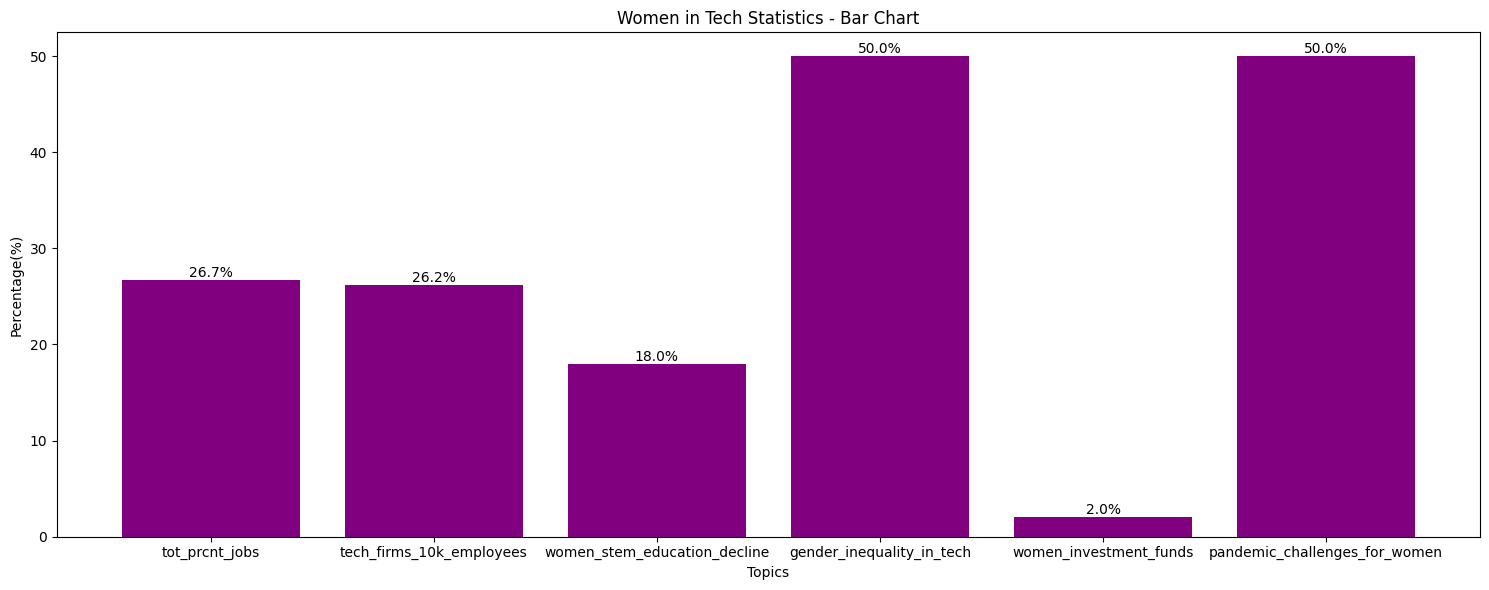

In [27]:
# Create bar charts for each topic and percentage
fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(df1["Topics"], df1["Percentage"], color='purple')
ax.set_xlabel('Topics')
ax.set_ylabel('Percentage(%)')
ax.set_title('Women in Tech Statistics - Bar Chart')
for bar in bars:       # Add percentage labels
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{height}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [28]:
# Add the "Source" column to the DataFrame 
# to provide the the link to the website in which data was extracted from
df1["Source"] = url

# Print the updated DataFrame
# Apply formatting to the table
styled_table = df1.style\
    .set_properties(subset=["Topics"], **{'background-color': '#e9e9e9', 'color': 'black'})\
    .set_properties(subset=["Statistics"], **{'background-color': '#f5f5f5', 'color': 'black'})\
    .set_properties(subset=["Percentage"], **{'background-color': '#f5f5f5', 'color': 'black'})\
    .set_properties(subset=["Source"], **{'background-color': '#f5f5f5', 'color': 'black'})\
    .set_caption("Women in Tech Statistics")\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#333333'), ('color', 'white'), ('text-align', 'left'), ('padding', '10px')]
    }])

# Display the styled table
display(styled_table)

/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_16193/3968928147.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Source"] = url


,Topics,Statistics,Percentage,Source
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related jobs.,26.700000,https://explodingtopics.com/blog/women-in-tech
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesreport women's representation at 26.2%.",26.200000,https://explodingtopics.com/blog/women-in-tech
4,women_stem_education_decline,"Despite equal access, the percentage of women pursuing STEM subjects in higher education is on the decline, andwomen achieve just 18% of new computer science degrees.",18.000000,https://explodingtopics.com/blog/women-in-tech
6,gender_inequality_in_tech,"More than50% of women in tech report gender inequality, discrimination, or sexual harassmentin environments dominated by men.",50.000000,https://explodingtopics.com/blog/women-in-tech
7,women_investment_funds,"In prior years, women have received as little as2% of all investment fundsin a given year and receive far less global venture capital funding than men.",2.000000,https://explodingtopics.com/blog/women-in-tech
8,pandemic_challenges_for_women,"The pandemic worsened many of the significant challenges that women face, with over50% of women reporting difficulties due to pandemic workplace changes.",50.000000,https://explodingtopics.com/blog/women-in-tech


                    Project Milestone 4:Connecting to an API/Pulling in the Data and Cleaning/Formatting
______________________________________________________________________________________
                                        

 **import all the libraries**
______________________________

In [29]:
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile
import os
import pandas as pd
import re
import numpy as np

**Kaggle API to extract the dataset**
_________________________________________

In [30]:
api = KaggleApi()
api.authenticate()

In [31]:
api.competition_list_files_cli(competition= 'salary-prediction-for-job-postings')

name                           size  creationDate         
----------------------------  -----  -------------------  
usjobs_train.csv                8MB  2023-11-08 14:12:23  
usjobs_test.csv                 5MB  2023-11-08 14:12:23  
usjobs_sample_submission.csv  627KB  2023-11-08 14:12:23  


In [32]:
api.competition_download_file('salary-prediction-for-job-postings', file_name= 'usjobs_train.csv')


usjobs_train.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [33]:
def unzip_file(file_path, extract_path):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

unzip_file('usjobs_train.csv.zip', ".")

**Read in the Data set for us jobs**
_____________________________________

In [34]:
df = pd.read_csv('usjobs_train.csv')
df.head()

,ID,Job,Jobs_Group,Profile,Remote,Company,Location,City,State,Frecuency_Salary,...,Skills,Sector,Sector_Group,Revenue,Employee,Company_Score,Reviews,Director,Director_Score,URL
0,job_f2c807527f687b96,"Part-time Reporting Business Analyst, Data & A...",Financial Analyst,NaN,Remote,Sandy Hook Promise Foundation,Remote,NaN,NaN,hour,...,"['Salesforce', 'Bachelor']",NGOs and Nonprofit Organizations,Nonprofit Organizations,NaN,XS,4.2,20.0,NaN,NaN,https://www.sandyhookpromise.org/
1,job_2660d4c53505af10,Controller,Controller,NaN,NaN,Building Service 32BJ Benefit Funds,"New York, NY 10013 (Tribeca area)",New York,NY,year,...,"['SQL', 'Master', 'Dynamics 365', 'Snowflake',...",NGOs and Nonprofit Organizations,Nonprofit Organizations,NaN,M,3.5,58.0,"Peter Goldberger, Executive Director",0.70,NaN
2,sj_50358c44328ae06a,Sr Finance Analyst,Financial Analyst,Senior,NaN,LCS,NaN,NaN,NaN,year,...,"['Word', 'Bachelor', 'Excel']",Personal Consumer Services,Sales,XXXS,XXXS,3.4,88.0,NaN,NaN,NaN
3,job_a087fd700e3e85f0,Senior Business Intelligence Analyst,Business Intelligence,Senior,Hybrid,Federal Reserve Bank of Richmond,"Richmond, VA 23219 (Central Office area)",Richmond,VA,year,...,"['PowerPoint', 'Power BI', 'Tableau', 'Word', ...",Banking and Credit Services,Finance,XXL,XL,3.8,30.0,Tom Barkin,0.70,https://www.richmondfed.org/
4,job_d2a2538a2c4d2033,Data Center Operations Analyst (Temporary Assi...,Operations Analyst,NaN,Remote,Los Angeles County Office of Education,"Downey, CA 90242+1 ubicación",Downey,CA,hour,...,['Office'],State and Regional Agencies,Government,NaN,XL,4.2,186.0,Debra Duardo,0.85,NaN


In [35]:
print(df.shape)

(33248, 21)


                                Step 1: Duplicates(Unique Values) and Null values
___________________________________________________

In [36]:
for column in df.columns:
    unique_values = len(df[column].value_counts())
    null_values = df[column].isna().sum()
    
    print(f"{column} Total Unique Values: {unique_values}")
    print(f"{column} Null Values Count: {null_values}")
    print()

ID Total Unique Values: 33248
ID Null Values Count: 0

Job Total Unique Values: 17227
Job Null Values Count: 0

Jobs_Group Total Unique Values: 14
Jobs_Group Null Values Count: 0

Profile Total Unique Values: 3
Profile Null Values Count: 21107

Remote Total Unique Values: 2
Remote Null Values Count: 19319

Company Total Unique Values: 13995
Company Null Values Count: 9

Location Total Unique Values: 12542
Location Null Values Count: 13

City Total Unique Values: 2951
City Null Values Count: 3824

State Total Unique Values: 54
State Null Values Count: 3112

Frecuency_Salary Total Unique Values: 5
Frecuency_Salary Null Values Count: 0

Mean_Salary Total Unique Values: 8454
Mean_Salary Null Values Count: 0

Skills Total Unique Values: 10805
Skills Null Values Count: 0

Sector Total Unique Values: 138
Sector Null Values Count: 7214

Sector_Group Total Unique Values: 28
Sector_Group Null Values Count: 7214

Revenue Total Unique Values: 9
Revenue Null Values Count: 18318

Employee Total Uniq

                                    Step 2:   drop columns with null values
___________________________________________________

In [37]:

null_threshold = len(df) * 0.2  # Set the threshold as 50% of total rows
columns_to_drop = []
for column in df.columns:
    null_values = df[column].isna().sum()
    
    if null_values > null_threshold:
        columns_to_drop.append(column)

df.drop(columns=columns_to_drop, inplace=True)

print(f"Columns dropped: {columns_to_drop}")

Columns dropped: ['Profile', 'Remote', 'Sector', 'Sector_Group', 'Revenue', 'Employee', 'Company_Score', 'Reviews', 'Director', 'Director_Score', 'URL']


In [38]:
df.isna().sum()


ID                     0
Job                    0
Jobs_Group             0
Company                9
Location              13
City                3824
State               3112
Frecuency_Salary       0
Mean_Salary            0
Skills                 0
dtype: int64

                                        Step 3:  Fix casing or inconsistent values
____________________________________________

In [39]:
#  Extract job title
df['Job'] = df['Job'].apply(lambda x: re.split('[,(]', x)[0].strip())
df

,ID,Job,Jobs_Group,Company,Location,City,State,Frecuency_Salary,Mean_Salary,Skills
0,job_f2c807527f687b96,Part-time Reporting Business Analyst,Financial Analyst,Sandy Hook Promise Foundation,Remote,NaN,NaN,hour,115000.000,"['Salesforce', 'Bachelor']"
1,job_2660d4c53505af10,Controller,Controller,Building Service 32BJ Benefit Funds,"New York, NY 10013 (Tribeca area)",New York,NY,year,185000.000,"['SQL', 'Master', 'Dynamics 365', 'Snowflake',..."
2,sj_50358c44328ae06a,Sr Finance Analyst,Financial Analyst,LCS,NaN,NaN,NaN,year,84500.000,"['Word', 'Bachelor', 'Excel']"
3,job_a087fd700e3e85f0,Senior Business Intelligence Analyst,Business Intelligence,Federal Reserve Bank of Richmond,"Richmond, VA 23219 (Central Office area)",Richmond,VA,year,111625.000,"['PowerPoint', 'Power BI', 'Tableau', 'Word', ..."
4,job_d2a2538a2c4d2033,Data Center Operations Analyst,Operations Analyst,Los Angeles County Office of Education,"Downey, CA 90242+1 ubicación",Downey,CA,hour,102690.400,['Office']
...,...,...,...,...,...,...,...,...,...,...
33243,job_51375f2d25e41629,Accounting Specialist I - Treasurer,Finance,Yavapai County Human Resources,"Prescott, AZ",Prescott,AZ,year,47206.495,"['English', 'Office']"
33244,job_af259ef51491c1fd,Treasurer Accounting Supervisor,Finance,Pinal County,"Florence, AZ 85132",Florence,AZ,year,79741.000,"['CPA', 'Office', 'Bachelor']"
33245,job_45519b91f601ab4c,FINANCIAL MANAGEMENT ANALYST,Financial Analyst,US Naval Air Systems Command,"Patuxent River, MD+1 ubicación",Patuxent River,MD,year,119908.000,"['Office', 'Bachelor']"
33246,job_25a66c0757505368,BA with Management of Change,Business Analyst,Source Mantra,"Houston, TX 77015",Houston,TX,hour,115000.000,['SQL']


In [40]:
#  Extract individual skills separated by commas
df['Skills'] = df['Skills'].apply(lambda x: x.strip(" '' "))
df

,ID,Job,Jobs_Group,Company,Location,City,State,Frecuency_Salary,Mean_Salary,Skills
0,job_f2c807527f687b96,Part-time Reporting Business Analyst,Financial Analyst,Sandy Hook Promise Foundation,Remote,NaN,NaN,hour,115000.000,"['Salesforce', 'Bachelor']"
1,job_2660d4c53505af10,Controller,Controller,Building Service 32BJ Benefit Funds,"New York, NY 10013 (Tribeca area)",New York,NY,year,185000.000,"['SQL', 'Master', 'Dynamics 365', 'Snowflake',..."
2,sj_50358c44328ae06a,Sr Finance Analyst,Financial Analyst,LCS,NaN,NaN,NaN,year,84500.000,"['Word', 'Bachelor', 'Excel']"
3,job_a087fd700e3e85f0,Senior Business Intelligence Analyst,Business Intelligence,Federal Reserve Bank of Richmond,"Richmond, VA 23219 (Central Office area)",Richmond,VA,year,111625.000,"['PowerPoint', 'Power BI', 'Tableau', 'Word', ..."
4,job_d2a2538a2c4d2033,Data Center Operations Analyst,Operations Analyst,Los Angeles County Office of Education,"Downey, CA 90242+1 ubicación",Downey,CA,hour,102690.400,['Office']
...,...,...,...,...,...,...,...,...,...,...
33243,job_51375f2d25e41629,Accounting Specialist I - Treasurer,Finance,Yavapai County Human Resources,"Prescott, AZ",Prescott,AZ,year,47206.495,"['English', 'Office']"
33244,job_af259ef51491c1fd,Treasurer Accounting Supervisor,Finance,Pinal County,"Florence, AZ 85132",Florence,AZ,year,79741.000,"['CPA', 'Office', 'Bachelor']"
33245,job_45519b91f601ab4c,FINANCIAL MANAGEMENT ANALYST,Financial Analyst,US Naval Air Systems Command,"Patuxent River, MD+1 ubicación",Patuxent River,MD,year,119908.000,"['Office', 'Bachelor']"
33246,job_25a66c0757505368,BA with Management of Change,Business Analyst,Source Mantra,"Houston, TX 77015",Houston,TX,hour,115000.000,['SQL']


In [41]:
# Location remove 

In [42]:
df['Location'] = df['Location'].dropna().apply(lambda x: re.split('[(+]', x)[0].strip())
df

,ID,Job,Jobs_Group,Company,Location,City,State,Frecuency_Salary,Mean_Salary,Skills
0,job_f2c807527f687b96,Part-time Reporting Business Analyst,Financial Analyst,Sandy Hook Promise Foundation,Remote,NaN,NaN,hour,115000.000,"['Salesforce', 'Bachelor']"
1,job_2660d4c53505af10,Controller,Controller,Building Service 32BJ Benefit Funds,"New York, NY 10013",New York,NY,year,185000.000,"['SQL', 'Master', 'Dynamics 365', 'Snowflake',..."
2,sj_50358c44328ae06a,Sr Finance Analyst,Financial Analyst,LCS,NaN,NaN,NaN,year,84500.000,"['Word', 'Bachelor', 'Excel']"
3,job_a087fd700e3e85f0,Senior Business Intelligence Analyst,Business Intelligence,Federal Reserve Bank of Richmond,"Richmond, VA 23219",Richmond,VA,year,111625.000,"['PowerPoint', 'Power BI', 'Tableau', 'Word', ..."
4,job_d2a2538a2c4d2033,Data Center Operations Analyst,Operations Analyst,Los Angeles County Office of Education,"Downey, CA 90242",Downey,CA,hour,102690.400,['Office']
...,...,...,...,...,...,...,...,...,...,...
33243,job_51375f2d25e41629,Accounting Specialist I - Treasurer,Finance,Yavapai County Human Resources,"Prescott, AZ",Prescott,AZ,year,47206.495,"['English', 'Office']"
33244,job_af259ef51491c1fd,Treasurer Accounting Supervisor,Finance,Pinal County,"Florence, AZ 85132",Florence,AZ,year,79741.000,"['CPA', 'Office', 'Bachelor']"
33245,job_45519b91f601ab4c,FINANCIAL MANAGEMENT ANALYST,Financial Analyst,US Naval Air Systems Command,"Patuxent River, MD",Patuxent River,MD,year,119908.000,"['Office', 'Bachelor']"
33246,job_25a66c0757505368,BA with Management of Change,Business Analyst,Source Mantra,"Houston, TX 77015",Houston,TX,hour,115000.000,['SQL']


                                            Extract state and zip code from location
__________________________________________

In [43]:
# Takeout the state from location
df['State_Extracted'] = df['Location'].dropna().apply(lambda x: re.search(r'(\w{2})\s*\d{5}', x).group(1) if re.search(r'(\w{2})\s*\d{5}', x) else '')
df['State_Extracted'].dropna()
df.drop(columns=['State','Frecuency_Salary'], inplace=True)

                                                 Identify outliers and bad data
________________________________________

In [44]:
# Identify outliers in salary column
z_scores = (df['Mean_Salary'].astype('int64') - df['Mean_Salary'].astype('int64').mean()) / df['Mean_Salary'].astype('int64').std()
threshold = 3  # Adjust the threshold if desired
outliers = df[np.abs(z_scores) > threshold]
outliers

,ID,Job,Jobs_Group,Company,Location,City,Mean_Salary,Skills,State_Extracted
187,job_f249a027413b6df0,Engineering Manager,ML/AI Engineer,"Grammarly, Inc.",United States,NaN,370000.0,"['Machine Learning', 'Artificial Intelligence']",
220,job_aa14df6887a2c79c,Chief Financial Officer,CFO,Pro Talent Solutions,"Brooklyn, NY 11221",Brooklyn,250000.0,"['CPA', 'Office', 'Bachelor']",NY
301,job_3ad0a42fcc2364ec,Director - US Treasury Capital Markets Counsel,CFO,Barclays,"New York, NY 10020",New York,295000.0,['Office'],NY
384,job_4abfc9929cb3aba3,Senior/ Staff Machine Learning Research Scientist,ML/AI Engineer,Nuro,"Mountain View, CA",Mountain View,252700.0,"['Python', 'C++', 'Deep Learning', 'Machine Le...",
556,job_1986fa39e76c9d03,Assistant Controller,Controller,Freshworks,"San Mateo, CA",San Mateo,254657.5,"['CPA', 'Bachelor', 'ERP']",
...,...,...,...,...,...,...,...,...,...
32617,job_6f283515f01d4b1a,Vice President and Chief Financial Officer,CFO,"AA Transportation Co., Inc.","Nashville, TN",Nashville,408450.0,"['CPA', 'Office']",
32668,job_202707d0613505dc,Machine Learning Scientist - Natural Language ...,ML/AI Engineer,JPMorgan Chase & Co,"New York, NY 10179",New York,262500.0,"['Tensor Flow', 'PhD', 'SciKit', 'Pandas', 'De...",NY
32728,job_25f8c0d279153a3d,Enterprise VP,Financial Analyst,Lincoln Financial,"Radnor, PA",Radnor,237950.5,"['PowerPoint', 'MBA', 'Excel', 'CPA', 'Bachelo...",
32809,job_9a6c44709bafe0f5,Sr. Machine Learning Engineer,ML/AI Engineer,Braintrust,"Austin, TX",Austin,325000.0,"['Tensor Flow', 'PhD', 'Machine Learning', 'Ar...",


In [45]:
df['Mean_Salary'] = df['Mean_Salary'].astype("int64")
df['Mean_Salary']

0        115000
1        185000
2         84500
3        111625
4        102690
          ...  
33243     47206
33244     79741
33245    119908
33246    115000
33247    155000
Name: Mean_Salary, Length: 33248, dtype: int64

                                Project Milestone 5: Merging the Data and Storing in a Database/Visualizing Data
__________________________

                                                    SQL CONNECTION
________________

In [46]:
# Create a SQLite database and connect to it
conn = sqlite3.connect('data.db')

In [47]:
# Load the datasets into separate tables
df1.to_sql('table1', conn, if_exists='replace', index=False)
df.to_sql('table2', conn, if_exists='replace', index=False)
subset_df.to_sql('table3', conn, if_exists='replace', index=False)

25973

In [48]:
# Create a data frame again from sql databases for kaggle_api_data
query1 = '''
SELECT *
FROM table2
'''
data1 = pd.read_sql_query(query1, conn)

In [49]:
# Create a data frame again from sql databases from csv data 
query2 ='''
SELECT *
FROM table3
'''
data2 = pd.read_sql_query(query2, conn)

In [50]:
# Create a data frame again from sql databases for webscraping table
query3 = '''
SELECT *
FROM table1
'''
data3 = pd.read_sql_query(query3, conn)

In [51]:
# Close the database connection
conn.close()

In [52]:
## there were some nan values in location so drop that and show df
data1 = data1.dropna(subset=['Location'])
data1 = data1.drop('ID', axis =1 )
data1

,Job,Jobs_Group,Company,Location,City,Mean_Salary,Skills,State_Extracted
0,Part-time Reporting Business Analyst,Financial Analyst,Sandy Hook Promise Foundation,Remote,None,115000,"['Salesforce', 'Bachelor']",
1,Controller,Controller,Building Service 32BJ Benefit Funds,"New York, NY 10013",New York,185000,"['SQL', 'Master', 'Dynamics 365', 'Snowflake',...",NY
3,Senior Business Intelligence Analyst,Business Intelligence,Federal Reserve Bank of Richmond,"Richmond, VA 23219",Richmond,111625,"['PowerPoint', 'Power BI', 'Tableau', 'Word', ...",VA
4,Data Center Operations Analyst,Operations Analyst,Los Angeles County Office of Education,"Downey, CA 90242",Downey,102690,['Office'],CA
5,Sr. Financial Analyst,Financial Analyst,Pharmavite LLC,"Valencia, CA 91355",Valencia,124650,"['Excel', 'PowerPoint', 'Bachelor', 'ERP']",CA
...,...,...,...,...,...,...,...,...
33243,Accounting Specialist I - Treasurer,Finance,Yavapai County Human Resources,"Prescott, AZ",Prescott,47206,"['English', 'Office']",
33244,Treasurer Accounting Supervisor,Finance,Pinal County,"Florence, AZ 85132",Florence,79741,"['CPA', 'Office', 'Bachelor']",AZ
33245,FINANCIAL MANAGEMENT ANALYST,Financial Analyst,US Naval Air Systems Command,"Patuxent River, MD",Patuxent River,119908,"['Office', 'Bachelor']",
33246,BA with Management of Change,Business Analyst,Source Mantra,"Houston, TX 77015",Houston,115000,['SQL'],TX


In [53]:
# show dataframe
data2

,age(in_years),gender,country,highest_lvl_educ,job_role,programming_exp(in_years),curr_industry,company_size,salary,programming_lang
0,50-54,Man,India,Bachelor’S Degree,Other,5-10 Years,Manufacturing/Fabrication,50-249 Employees,"25,000-29,999","Python, R"
1,50-54,Man,Indonesia,Master’S Degree,Program/Project Manager,20+ Years,Manufacturing/Fabrication,"1000-9,999 Employees","60,000-69,999","Nan, Sql, C, C++, Java"
2,22-24,Man,Pakistan,Master’S Degree,Software Engineer,1-3 Years,Academics/Education,"1000-9,999 Employees",$0-999,"Python, C++, Java"
3,45-49,Man,Mexico,Doctoral Degree,Research Scientist,20+ Years,Academics/Education,"1000-9,999 Employees","30,000-39,999",Python
4,45-49,Man,India,Doctoral Degree,Other,< 1 Years,Academics/Education,50-249 Employees,"30,000-39,999","Python, C, Matlab"
...,...,...,...,...,...,...,...,...,...,...
25968,30-34,Man,Egypt,Bachelor’S Degree,Data Analyst,1-3 Years,Computers/Technology,"10,000 Or More Employees","15,000-19,999","Python, Sql, Javascript, Bash"
25969,22-24,Man,China,Master’S Degree,Student,1-3 Years,None,None,None,Python
25970,50-54,Man,Sweden,Doctoral Degree,Research Scientist,I Have Never Written Code,Academics/Education,"1000-9,999 Employees",$0-999,
25971,45-49,Man,United States Of America,Master’S Degree,Data Scientist,5-10 Years,Online Service/Internet-Based Services,"10,000 Or More Employees",None,"Python, Sql"


In [54]:
#show dataframe
data3.head()

,Topics,Statistics,Percentage,Source
0,tot_prcnt_jobs,Women currently hold only26.7%of tech-related ...,26.7,https://explodingtopics.com/blog/women-in-tech
1,tech_firms_10k_employees,"Tech firms with more than10,000 employeesrepor...",26.2,https://explodingtopics.com/blog/women-in-tech
2,women_stem_education_decline,"Despite equal access, the percentage of women ...",18.0,https://explodingtopics.com/blog/women-in-tech
3,gender_inequality_in_tech,More than50% of women in tech report gender in...,50.0,https://explodingtopics.com/blog/women-in-tech
4,women_investment_funds,"In prior years, women have received as little ...",2.0,https://explodingtopics.com/blog/women-in-tech


In [55]:
#convert all column names to lower case to have a consistent naming convention throughout
data3.columns = data3.columns.str.lower()
data2.columns = data2.columns.str.lower()
data1.columns = data1.columns.str.lower()

                         merge the data 2 and 2 tpgether since data3 doesnt match the format to merge
__________

In [56]:
data = data1.rename(columns={'job': 'job_role', 'state_extracted': 'state', 'age(in_years)': 'age'})
data.columns

Index(['job_role', 'jobs_group', 'company', 'location', 'city', 'mean_salary',
       'skills', 'state'],
      dtype='object')

_Note_ : _Since we want to cosolidate all datasets from sql, we need to merge them on job role. Becasue in milestone 2, we have already seprated the jobs that are related to data and cut off the rest. So Here we will use that list to do an inner join on the data._
__________________

In [57]:
# merged_data = pd.merge(data, data2, on='job_role', how='left')
# merged_data

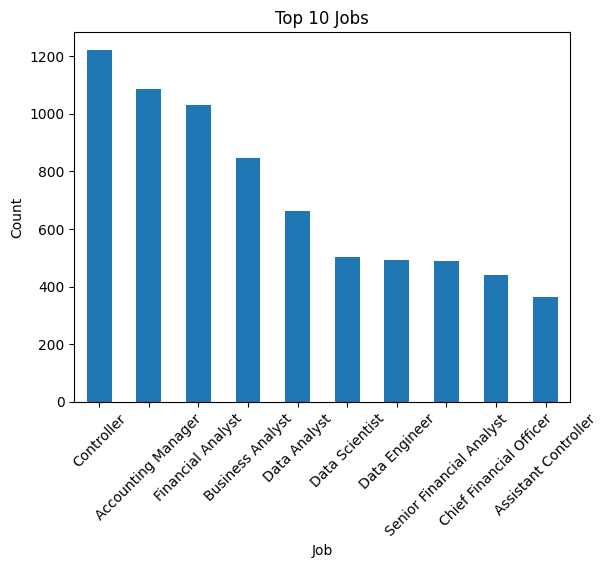

In [58]:
# Visualization for different jobs
job_counts = data['job_role'].value_counts().head(10) # Select top 10 jobs by count
job_counts.plot(kind='bar', xlabel='Job', ylabel='Count', title='Top 10 Jobs')
plt.xticks(rotation=45)
plt.show()

                        Word cloud for skills and Job titles
____________________________

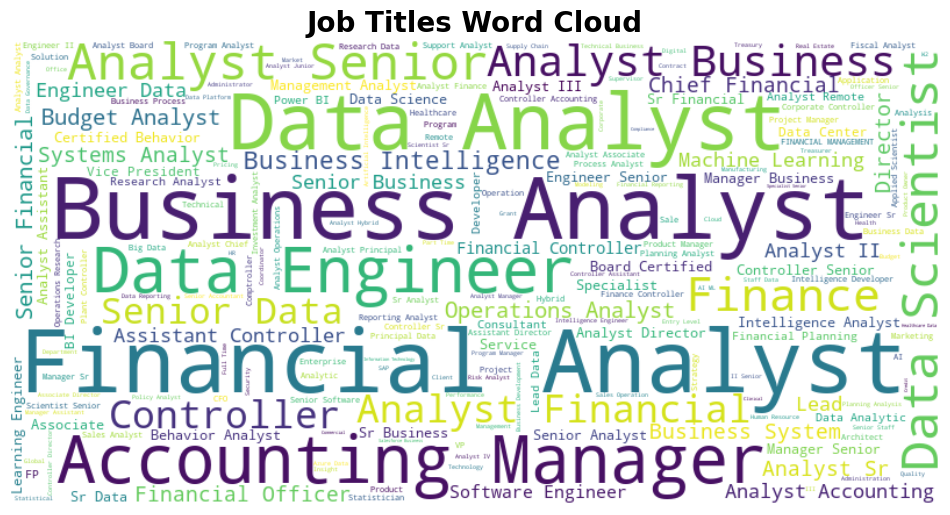

In [59]:
# Word cloud for job titles
job_titles = ' '.join(data['job_role'])
job_title_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(job_titles)
plt.figure(figsize=(12, 8))
plt.imshow(job_title_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Job Titles Word Cloud', fontweight = 'bold', fontsize = 20)
plt.show()

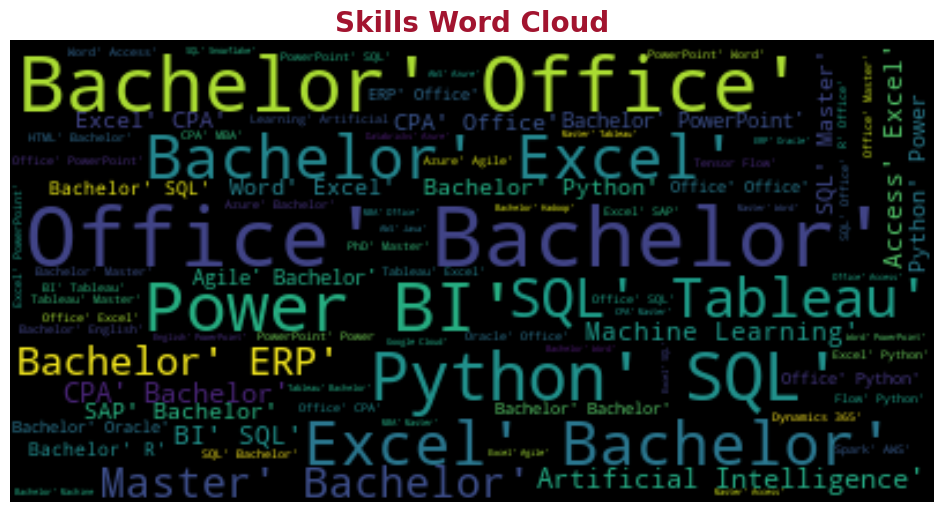

In [60]:
# Word cloud for skills
skills = data['skills'].dropna().str.cat(sep=' ')
skills_wordcloud = WordCloud().generate(skills)
plt.figure(figsize=(12, 6))
plt.imshow(skills_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Skills Word Cloud', color = "#A2142F" , fontweight = 'bold', fontsize = 20)
plt.show()